In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the data from the Excel file
df = pd.read_excel('data/irrigations.xlsx')
df.head()

,moisture_before,moisture_after,duration,moisture_gain,moisture_rate
0,36.8,79.6,6.61,42.8,6.48
1,38.1,79.8,7.02,41.7,5.94
2,37.0,80.1,7.16,43.1,6.02
3,37.3,80.8,7.09,43.5,6.14
4,40.0,80.4,4.72,40.4,8.56


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   moisture_before  117 non-null    float64
 1   moisture_after   117 non-null    float64
 2   duration         117 non-null    float64
 3   moisture_gain    117 non-null    float64
 4   moisture_rate    117 non-null    float64
dtypes: float64(5)
memory usage: 4.7 KB


In [4]:
df.describe()

,moisture_before,moisture_after,duration,moisture_gain,moisture_rate
count,117.000000,117.000000,117.000000,117.000000,117.000000
mean,41.715385,78.601709,5.821966,36.886325,6.150000
std,9.646230,5.617368,2.830243,14.236118,2.608637
min,32.600000,60.000000,0.000000,-1.000000,0.000000
25%,35.700000,79.800000,4.630000,39.300000,4.890000
50%,37.300000,80.300000,6.800000,42.900000,6.210000
75%,41.100000,80.900000,7.340000,45.100000,8.050000
max,63.300000,81.500000,9.820000,47.700000,11.390000


### Train Test Split

In [12]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=23)

print("Train count:", len(df_train))
print("Test count:", len(df_test))

Train count: 93
Test count: 24


In [7]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_transformed = scaler.fit_transform(df_train)
test_transformed = scaler.transform(df_test)

In [8]:
print("Training Transformed:")
print(train_transformed[:3])
print("Test Transformed:")
print(test_transformed[:3])

Training Transformed:
[[-0.06407065  0.41734872 -0.37886016  0.20631238  0.81229166]
 [-0.39026973  0.30228914  1.2401589   0.38535173 -0.66139743]
 [ 1.82788406  0.39817213 -1.38427839 -1.09918293  1.66918391]]
Test Transformed:
[[-0.83607515  0.16805297  0.57111221  0.63899082 -0.01976314]
 [ 2.11058994 -3.62891312 -2.21596626 -2.85973661 -2.56146287]
 [-0.50987607  0.20640616  1.08121411  0.43011157 -0.54134973]]


In [37]:
# Save scaler fit
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

#### Hyperparameter Tuner

In [38]:
from keras.models import Model
from keras.layers import Dense

In [39]:
from keras_tuner.tuners import GridSearch
from keras_tuner import Objective
from keras.layers import Input

In [40]:
input_dim = train_transformed.shape[1]

In [41]:
def build_model(hp):
    # Jumlah hidden layer encoder
    num_layers = hp.Int('num_layers', min_value=1, max_value=3)

    # Membuat arsitektur  encoder dengan layer menurun
    units_0 = hp.Choice('units_0', [5, 4, 3])
    encoder_units = [units_0]
    if num_layers >= 2:
        units_1 = hp.Choice('units_1', [u for u in [4, 3, 2] if u < units_0])
        encoder_units.append(units_1)
    if num_layers >= 3:
        units_2 = hp.Choice('units_2', [u for u in [3, 2, 1] if u < units_1])
        encoder_units.append(units_2)

    # Input
    inputs = Input(shape=(input_dim,))
    x = inputs

    # Encoder
    for units in encoder_units:
        x = Dense(units, activation='relu')(x)

    # Latent space
    latent_dim = hp.Choice('latent_dim', [1, 2])
    latent = Dense(latent_dim, activation='relu', name='latent')(x)
    x = latent

    # Decoder
    for units in reversed(encoder_units):
        x = Dense(units, activation='relu')(x)

    # Output
    outputs = Dense(input_dim, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

In [42]:
tuner = GridSearch(hypermodel=build_model, objective=Objective('val_loss', direction='min'),
    directory='tuner_results', project_name='smart_irrigation_system')

In [43]:
tuner.search(
    train_transformed, 
    train_transformed, 
    epochs=25, 
    batch_size=1000, 
    validation_data=(test_transformed, test_transformed))

Trial 78 Complete [00h 00m 07s]
val_loss: 1.600458025932312

Best val_loss So Far: 1.2541446685791016
Total elapsed time: 00h 11m 28s


In [44]:
tuner.results_summary()

Results summary
Results in tuner_results\smart_irrigation_system
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0024 summary
Hyperparameters:
num_layers: 3
units_0: 5
latent_dim: 1
units_1: 4
units_2: 3
Score: 1.2541446685791016

Trial 0063 summary
Hyperparameters:
num_layers: 3
units_0: 3
latent_dim: 1
units_1: 3
units_2: 3
Score: 1.5511480569839478

Trial 0004 summary
Hyperparameters:
num_layers: 1
units_0: 3
latent_dim: 1
Score: 1.5649968385696411

Trial 0001 summary
Hyperparameters:
num_layers: 1
units_0: 5
latent_dim: 2
Score: 1.5681047439575195

Trial 0010 summary
Hyperparameters:
num_layers: 2
units_0: 5
latent_dim: 2
units_1: 3
Score: 1.5690923929214478

Trial 0054 summary
Hyperparameters:
num_layers: 3
units_0: 4
latent_dim: 2
units_1: 3
units_2: 3
Score: 1.5729551315307617

Trial 0007 summary
Hyperparameters:
num_layers: 2
units_0: 5
latent_dim: 1
units_1: 3
Score: 1.5763417482376099

Trial 0036 summary
Hyperparameters:
num_layers: 3
units_0: 5
late

In [45]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150 (600.00 B)

 Trainable params: 150 (600.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = best_model.fit(train_transformed, 
               train_transformed, 
               epochs=400, 
               batch_size=1000, 
               validation_data=(test_transformed, test_transformed))

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.8098 - mae: 0.6587 - val_loss: 1.2455 - val_mae: 0.8363
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.8047 - mae: 0.6566 - val_loss: 1.2365 - val_mae: 0.8330
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.7994 - mae: 0.6546 - val_loss: 1.2273 - val_mae: 0.8297
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.7942 - mae: 0.6525 - val_loss: 1.2184 - val_mae: 0.8264
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.7891 - mae: 0.6506 - val_loss: 1.2096 - val_mae: 0.8230
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.7842 - mae: 0.6486 - val_loss: 1.2011 - val_mae: 0.8195
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.7792 - mae: 0.6464 - val_loss: 1.1927 - val_mae: 0.8158
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.7743 - mae: 0.6440 - val_loss: 1.1845 - val_mae: 0.8119
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.7693 - mae

### Analisis Histori Training

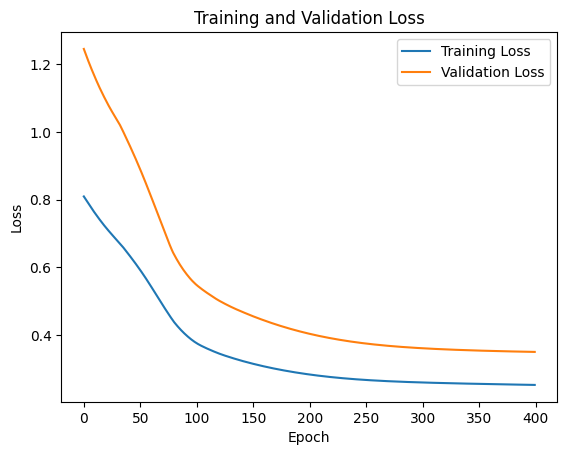

In [47]:
# Visualise the history of training
plt.plot(history.history['loss'], label= "Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [48]:
recon_train = best_model.predict(train_transformed)
recon_train_loss = np.mean(np.abs(train_transformed - recon_train), axis=1)
print("recon_train_loss:", recon_train_loss[:5])
print("Average reconstruction loss for training set:", np.mean(recon_train_loss))

recon_test = best_model.predict(test_transformed)
recon_test_loss = np.mean(np.abs(test_transformed - recon_test), axis=1)
print("recon_test_loss:", recon_test_loss[:5])
print("Average reconstruction loss for test set:", np.mean(recon_test_loss))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
recon_train_loss: [0.308695   0.37796527 1.02089995 0.08535987 0.08631343]
Average reconstruction loss for training set: 0.35001928682069555
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
recon_test_loss: [0.28234709 0.56773725 0.37399848 0.32727026 0.3131142 ]
Average reconstruction loss for test set: 0.4324965754830594


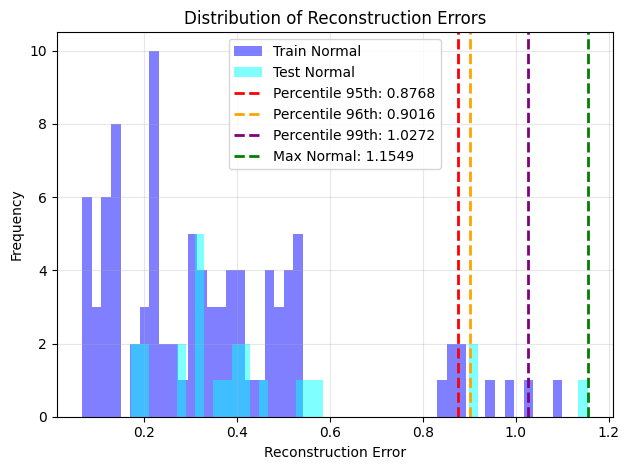

In [52]:
max_normal = max(np.max(recon_train_loss), np.max(recon_test_loss))
percentile_95_normal = np.percentile(recon_train_loss, 95)
percentile_96_normal = np.percentile(recon_train_loss, 96)
percentile_99_normal = np.percentile(recon_train_loss, 99)

# Plot distribusi histogram
plt.hist(recon_train_loss, bins=50, alpha=0.5, label='Train Normal', color='blue')
plt.hist(recon_test_loss, bins=50, alpha=0.5, label='Test Normal', color='cyan')
plt.axvline(percentile_95_normal, color='red', linestyle='--', linewidth=2, label=f'Percentile 95th: {percentile_95_normal:.4f}')
plt.axvline(percentile_96_normal, color='orange', linestyle='--', linewidth=2, label=f'Percentile 96th: {percentile_96_normal:.4f}')
plt.axvline(percentile_99_normal, color='purple', linestyle='--', linewidth=2, label=f'Percentile 99th: {percentile_99_normal:.4f}')
plt.axvline(max_normal, color='green', linestyle='--', linewidth=2, label=f'Max Normal: {max_normal:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# choose threshold
threshold = percentile_96_normal
print("Chosen threshold:", threshold)

Chosen threshold: 0.9016293181906735


In [51]:
# Save the best model
best_model.save('best_model.keras')